# What did the HRRR analysis say about the storm environment over central Oklahoma at 20 UTC, and how far was the tornado report from the most favorable values?

Open one HRRR analysis file, pull surface CAPE and 0-3 km storm-relative
helicity out of its 170 GRIB2 messages, and compare the values at the grid point
nearest an Oklahoma tornado report with the largest values within 100 km of that
point. The comparison is spatial and lives inside a single analysis hour: it
shows where the model placed the most favorable environment relative to the
report location, and it is not a statement about the air the storm actually
ingested.

Requires **usdata v0.15.0 or later** and the repository's examples environment
with the `grib` extra (`just notebooks`). The one locked source is the HRRR
20 UTC surface analysis for 2024-05-06: a whole CONUS grid, about 150 MB. The
service does no subsetting, so the entire file is downloaded and every field and
area is chosen locally. Run every cell in order. Saved outputs are a dated
snapshot; keep the manifest, lockfile, and raw bytes with your own analysis.


In [1]:
import sys
import time
from datetime import UTC, datetime
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Geod

from usdata import pull, verify

manifest = Path("dataset.yaml")
notebook_started = time.perf_counter()
print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
print({name: version(name) for name in ("usdata", "xarray", "eccodes", "pyproj", "matplotlib")})

Executed UTC: 2026-09-15T23:31:44+00:00
Python: 3.14.7
{'usdata': '0.16.0', 'xarray': '2026.7.0', 'eccodes': '2.48.0', 'pyproj': '3.8.0', 'matplotlib': '3.11.1'}


## 1. One run, one file

The manifest names a single HRRR run by its initialization window. `cycle: 20`
picks the run started at 20:00 UTC on 2024-05-06 and `forecast_hour: 0` picks
the analysis, the model's own best estimate of the atmosphere at that
initialization time rather than a projection forward from it. Forecast hour 1
of the same run would be a one-hour forecast valid at 21 UTC.

An analysis is still model output. It is a short assimilation cycle's blend of a
previous HRRR forecast with observations, on the model's own 3 km grid and with
the model's own physics, so a value at a point is what the model believes, not
what an instrument measured there.

The whole file is 150 MB because `noaa:hrrr` has only temporal subsetting: the
query selects which run and hour to download, never which fields or which part
of the grid.


In [2]:
print(manifest.read_text().strip())

started = time.perf_counter()
(item,) = pull(manifest).fetched
pull_seconds = time.perf_counter() - started
assert verify(manifest) == []
megabytes = item.provenance.size / 1e6
print("\nPull seconds:", round(pull_seconds, 2))
print(
    f"Source bytes: {item.provenance.size}"
    f" ({megabytes:.1f} MB, {megabytes / pull_seconds:.0f} MB/s)"
)
print("Source URL:", item.provenance.source_url)
print("Checksum:", item.provenance.checksum)
print("Asset id:", item.asset.id)
print("Valid time:", item.asset.time.start.isoformat())
print("Media type:", item.asset.media_type)

name: oklahoma-hrrr-analysis
sources:
  - dataset: noaa:hrrr
    start: 2024-05-06T20:00:00Z
    end: 2024-05-06T20:00:00Z
    params:
      cycle: 20
      forecast_hour: 0



Pull seconds: 4.28
Source bytes: 150114757 (150.1 MB, 35 MB/s)
Source URL: s3://noaa-hrrr-bdp-pds/hrrr.20240506/conus/hrrr.t20z.wrfsfcf00.grib2
Checksum: sha256:0f67cd6e1edd9d0876cb1a23459e9db59c892f7345e6a74b645b663302b7655c
Asset id: hrrr.20240506.t20z.wrfsfcf00.grib2
Valid time: 2024-05-06T20:00:00+00:00
Media type: application/x-grib2


## 2. Two fields out of 170 messages

A GRIB2 file is a stack of independent messages, one per field and level, so the
reader refuses to guess. Calling `open()` with no `select` raises a `ValueError`
whose message is the file's whole inventory of
`(shortName, typeOfLevel, level)` triples. That listing is the practical way to
find out what a run carries; the cell below catches it and prints its opening
rather than saving an error output.

`select` takes ecCodes keys and matches every message that satisfies all of
them, so two short names crossed with two level types return four variables, not
two. When more than one message survives, the reader renames each variable to
`shortName_typeOfLevel_level`, which is how `cape_surface_0` and
`hlcy_heightAboveGroundLayer_3000` get their names. The two extras here,
`cape_heightAboveGroundLayer_0` and `hlcy_heightAboveGroundLayer_1000`, are
0-3 km layer CAPE and 0-1 km helicity; they are decoded because the select
matched them, and the analysis below ignores them.


In [3]:
listing = ""
try:
    item.open()
except ValueError as exc:
    listing = str(exc)
assert listing.startswith("170 messages"), listing[:120]
print("Inventory message characters:", len(listing))
print(listing[:260], "...")

started = time.perf_counter()
fields = item.open(
    select={"shortName": ["cape", "hlcy"], "typeOfLevel": ["surface", "heightAboveGroundLayer"]}
)
print("\nDecode seconds:", round(time.perf_counter() - started, 2))
pd.DataFrame(
    {
        "variable": name,
        "long_name": variable.attrs["name"],
        "typeOfLevel": variable.attrs["typeOfLevel"],
        "level": variable.attrs["level"],
        "units": variable.attrs["units"],
        "valid_time": variable.attrs["valid_time"],
        "shape": str(variable.shape),
    }
    for name, variable in fields.data_vars.items()
)

Inventory message characters: 5817
170 messages; pass select={...} with ecCodes keys to choose, for example select={'shortName': ..., 'typeOfLevel': ...}. Available (shortName, typeOfLevel, level): ('refc', 'atmosphere', '0'), ('unknown', 'cloudTop', '0'), ('unknown', 'atmosphere', '0'), ('veri ...



Decode seconds: 1.29


,variable,long_name,typeOfLevel,level,units,valid_time,shape
0,cape_surface_0,Convective available potential energy,surface,0,J kg**-1,2024-05-06T20:00:00+00:00,"(1059, 1799)"
1,hlcy_heightAboveGroundLayer_3000,Storm relative helicity,heightAboveGroundLayer,3000,m**2 s**-2,2024-05-06T20:00:00+00:00,"(1059, 1799)"
2,hlcy_heightAboveGroundLayer_1000,Storm relative helicity,heightAboveGroundLayer,1000,m**2 s**-2,2024-05-06T20:00:00+00:00,"(1059, 1799)"
3,cape_heightAboveGroundLayer_0,Convective available potential energy,heightAboveGroundLayer,0,J kg**-1,2024-05-06T20:00:00+00:00,"(1059, 1799)"


## 3. The report, and the grid point nearest it

The reference point is the start of Storm Events report
[1184052](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052), an
EF1 tornado in Oklahoma County. Its coordinates and UTC start time are the ones
the [event context example](https://usdata.dev/examples/event-context/) and the
[tornado classification example](https://usdata.dev/examples/tornado-classification/)
resolve from the Storm Events archive, written here as constants so this
notebook downloads only the model file.

The gap matters and the cell prints it: the analysis is valid at 20:00 UTC on
2024-05-06 and the report begins at 04:39 UTC on 2024-05-07, so the analysis
precedes the report by more than eight hours. This example reads the environment
the model drew that afternoon over the region the storms later crossed. It does
not read the environment at the moment of the report.

HRRR stores longitudes in the 0 to 360 convention and puts latitude and
longitude in two-dimensional coordinate arrays, because the grid is Lambert
conformal rather than a regular latitude/longitude mesh. Distances here are
geodesic on WGS84 through `pyproj`, not differences of degrees, so a kilometre
means the same thing in every direction.


In [4]:
REPORT_ID = "1184052"
REPORT_LAT, REPORT_LON = 35.378, -97.543
REPORT_UTC = datetime(2024, 5, 7, 4, 39, tzinfo=UTC)
RADIUS_KM = 100.0

valid_time = item.asset.time.start
offset = REPORT_UTC - valid_time
print("Analysis valid:", valid_time.isoformat())
print(f"Report {REPORT_ID} begins:", REPORT_UTC.isoformat())
print(f"Report follows the analysis by {offset} ({offset.total_seconds() / 3600:.2f} hours)")

cape = fields["cape_surface_0"]
helicity = fields["hlcy_heightAboveGroundLayer_3000"]
latitudes = fields.latitude.values
stored = fields.longitude.values
longitudes = np.where(stored > 180, stored - 360, stored)
print(
    f"\nGrid {cape.shape[0]} x {cape.shape[1]} points · stored longitudes"
    f" {stored.min():.1f} to {stored.max():.1f} degrees east"
)

rows, cols = np.where(
    (np.abs(latitudes - REPORT_LAT) <= 2.0) & (np.abs(longitudes - REPORT_LON) <= 2.4)
)
window = (slice(rows.min(), rows.max() + 1), slice(cols.min(), cols.max() + 1))
box_lat, box_lon = latitudes[window], longitudes[window]
box = {"surface CAPE": cape.values[window], "0-3 km helicity": helicity.values[window]}

geod = Geod(ellps="WGS84")
_, _, metres = geod.inv(
    np.full(box_lat.shape, REPORT_LON), np.full(box_lat.shape, REPORT_LAT), box_lon, box_lat
)
distance_km = metres / 1000.0
nearest = np.unravel_index(int(distance_km.argmin()), distance_km.shape)
inside = distance_km <= RADIUS_KM
print(f"Window around the report: {box_lat.shape[0]} x {box_lat.shape[1]} grid points")
print(
    f"Nearest grid point: {box_lat[nearest]:.4f} N {box_lon[nearest]:.4f} E,"
    f" {distance_km[nearest]:.2f} km from the report (grid spacing is 3 km)"
)
print(f"Grid points within {RADIUS_KM:.0f} km: {int(inside.sum())}")
for name, values in box.items():
    print(f"At that grid point, {name}: {values[nearest]:.0f}")

Analysis valid: 2024-05-06T20:00:00+00:00
Report 1184052 begins: 2024-05-07T04:39:00+00:00
Report follows the analysis by 8:39:00 (8.65 hours)

Grid 1059 x 1799 points · stored longitudes 225.9 to 299.1 degrees east
Window around the report: 150 x 149 grid points
Nearest grid point: 35.3693 N -97.5388 E, 1.04 km from the report (grid spacing is 3 km)
Grid points within 100 km: 3505
At that grid point, surface CAPE: 3560
At that grid point, 0-3 km helicity: 134


## 4. The most favorable values within 100 km

A single grid point is one 3 km cell, and a cell's value is not the storm's
inflow. The honest comparison is between that cell and the distribution of the
same field over a neighbourhood, so the table reports, for each field inside the
100 km circle: the value at the report's cell, the median, the 95th percentile,
the maximum, where the maximum sits relative to the report, the percentile rank
of the report's own value, and the mean of the field within 15 km of the maximum,
which shows whether the peak cell is a real local maximum or a lone spike.

The radius is an analysis choice, not something the package supplies. One
hundred kilometres is roughly the area a supercell can traverse in an hour, and
it keeps the comparison inside central Oklahoma. A larger radius reaches into a
different air mass and the maxima move with it.


In [5]:
summary = []
maxima = {}
for name, values in box.items():
    at_report = float(values[nearest])
    peak = np.unravel_index(int(np.argmax(np.where(inside, values, -np.inf))), values.shape)
    maxima[name] = peak
    azimuth, _, metres_to_peak = geod.inv(
        REPORT_LON, REPORT_LAT, float(box_lon[peak]), float(box_lat[peak])
    )
    _, _, around_peak = geod.inv(
        np.full(box_lat.shape, float(box_lon[peak])),
        np.full(box_lat.shape, float(box_lat[peak])),
        box_lon,
        box_lat,
    )
    pool = values[inside]
    summary.append(
        {
            "field": name,
            "at_report_point": round(at_report, 1),
            "median_in_radius": round(float(np.median(pool)), 1),
            "p95_in_radius": round(float(np.percentile(pool, 95)), 1),
            "max_in_radius": round(float(values[peak]), 1),
            "mean_15km_of_max": round(float(values[around_peak / 1000.0 <= 15.0].mean()), 1),
            "km_to_max": round(metres_to_peak / 1000.0, 1),
            "bearing_to_max_deg": round(azimuth % 360, 1),
            "report_percentile": round(float((pool <= at_report).mean() * 100), 1),
        }
    )
azimuth, _, between = geod.inv(
    float(box_lon[maxima["surface CAPE"]]),
    float(box_lat[maxima["surface CAPE"]]),
    float(box_lon[maxima["0-3 km helicity"]]),
    float(box_lat[maxima["0-3 km helicity"]]),
)
print("Units: surface CAPE in J/kg, 0-3 km storm-relative helicity in m2/s2")
print(f"The two maxima are {between / 1000.0:.1f} km apart")
pd.DataFrame(summary)

Units: surface CAPE in J/kg, 0-3 km storm-relative helicity in m2/s2
The two maxima are 40.8 km apart


,field,at_report_point,median_in_radius,p95_in_radius,max_in_radius,mean_15km_of_max,km_to_max,bearing_to_max_deg,report_percentile
0,surface CAPE,3560.0,3500.0,4030.0,4480.0,3978.7,73.4,319.5,56.0
1,0-3 km helicity,134.0,139.0,208.0,250.0,200.1,81.1,349.6,41.1


## 5. One map

Surface CAPE is shaded and 0-3 km helicity is contoured over the same window, so
the two ingredients can be read against each other. The colour limits are
clipped to 1500 and 4800 J/kg to show the gradient across this window; values
outside the window and outside those limits exist. The dashed circle is the
100 km radius used above, and the two markers are the maxima from the table.


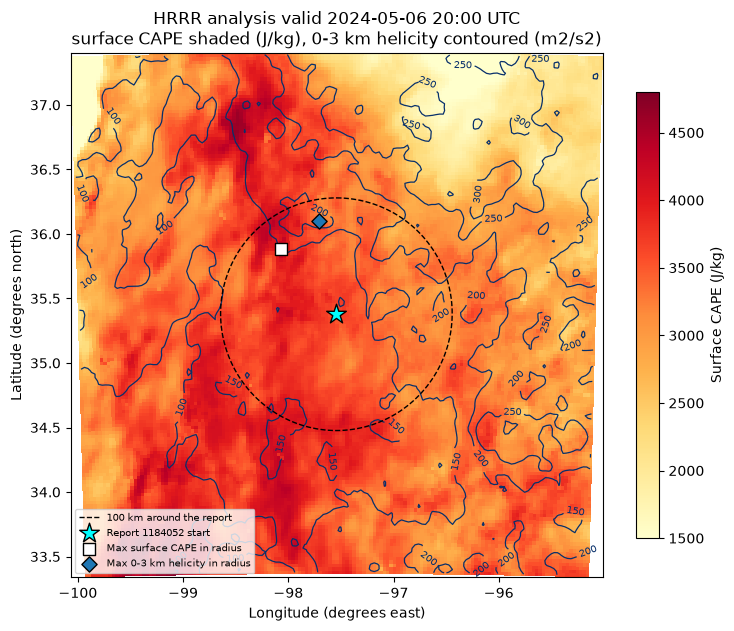

In [6]:
circle_lon, circle_lat, _ = geod.fwd(
    np.full(181, REPORT_LON),
    np.full(181, REPORT_LAT),
    np.linspace(0, 360, 181),
    np.full(181, RADIUS_KM * 1000),
)
cape_peak = maxima["surface CAPE"]
helicity_peak = maxima["0-3 km helicity"]

fig, ax = plt.subplots(figsize=(8.0, 6.2), layout="constrained")
mesh = ax.pcolormesh(
    box_lon, box_lat, box["surface CAPE"], cmap="YlOrRd", shading="auto", vmin=1500, vmax=4800
)
lines = ax.contour(
    box_lon,
    box_lat,
    box["0-3 km helicity"],
    levels=[100, 150, 200, 250, 300],
    colors="#08306b",
    linewidths=0.9,
)
ax.clabel(lines, fmt="%d", fontsize=7)
ax.plot(
    circle_lon,
    circle_lat,
    color="black",
    linewidth=1.0,
    linestyle="--",
    label=f"{RADIUS_KM:.0f} km around the report",
)
ax.scatter(
    REPORT_LON,
    REPORT_LAT,
    marker="*",
    s=220,
    c="cyan",
    edgecolors="black",
    zorder=3,
    label=f"Report {REPORT_ID} start",
)
ax.scatter(
    box_lon[cape_peak],
    box_lat[cape_peak],
    marker="s",
    s=70,
    c="white",
    edgecolors="black",
    zorder=3,
    label="Max surface CAPE in radius",
)
ax.scatter(
    box_lon[helicity_peak],
    box_lat[helicity_peak],
    marker="D",
    s=60,
    c="#1f77b4",
    edgecolors="black",
    zorder=3,
    label="Max 0-3 km helicity in radius",
)
ax.set(
    xlabel="Longitude (degrees east)",
    ylabel="Latitude (degrees north)",
    title=(
        "HRRR analysis valid 2024-05-06 20:00 UTC\n"
        "surface CAPE shaded (J/kg), 0-3 km helicity contoured (m2/s2)"
    ),
    aspect=1 / np.cos(np.deg2rad(REPORT_LAT)),
)
ax.legend(loc="lower left", fontsize=7)
fig.colorbar(mesh, ax=ax, label="Surface CAPE (J/kg)", shrink=0.85)
plt.show()
plt.close(fig)

## What the numbers say, and what they do not

**What they say.** In the 20 UTC analysis the grid point nearest report 1184052
held about 3560 J/kg of surface CAPE and about 134 m2/s2 of 0-3 km
storm-relative helicity. Within 100 km, the largest values were about
4480 J/kg of CAPE, 73 km away on a bearing of 320 degrees, and about
250 m2/s2 of helicity, 81 km away on a bearing of 350 degrees. Those two maxima
are 41 km apart from each other, both north to northwest of the report. The
report's own cell sat near the middle of both local distributions, at the 56th
percentile for CAPE and the 41st percentile for helicity.

**What they do not say.**

- **The analysis is eight hours and thirty-nine minutes before the report.**
  Instability, shear, and the boundaries that organize them all moved during
  that time. Nothing here verifies the environment at 04:39 UTC. The run whose
  analysis is valid then is `cycle: 4`, `forecast_hour: 0` on 2024-05-07, which
  is a different 150 MB file and a different notebook.
- **A grid point is not an inflow parcel.** Each value is a 3 km cell average in
  a model, and a storm ingests air over tens of kilometres. The percentile
  ranks above are a better description of the report's position in the field
  than the single-cell numbers are.
- **Distance to a maximum is not a physical lead.** The two peaks are real
  local maxima rather than lone spikes: averaged within 15 km of them the fields
  are 3979 J/kg and 200 m2/s2, against radius medians of 3500 J/kg and
  139 m2/s2. They are still one cell of one run, though, and 73 or 81 km is a
  distance on a map at one instant, not a measure of how much better or worse
  the storm's own environment was.
- **CAPE and helicity are not a tornado forecast.** Favorable values appear on
  many days without tornadoes, and this one analysis has no storm-scale
  information, no convective initiation, and no report data in it at all.
- **This is one model's estimate.** A second opinion needs an independent
  source. The [GFS example](https://usdata.dev/examples/gfs-environment/) reads
  the same two fields from the global analysis at a much coarser resolution.


## 6. Verify and reuse the locked file

A second pull must find the same bytes in the cache and repeat no download. The
lockfile pins the object name and its SHA-256, so an upstream replacement would
surface as a verification failure rather than as a silently different answer.
This notebook deliberately does not exercise restoration into an empty cache,
because that would download the 150 MB file a second time; the
[weather and streamflow example](https://usdata.dev/examples/weather-and-streamflow/)
demonstrates that path on small inputs.


In [7]:
started = time.perf_counter()
again = pull(manifest)
assert again.from_lockfile and all(cached.from_cache for cached in again.fetched)
assert verify(manifest) == []
print("Cached pull seconds:", round(time.perf_counter() - started, 3))
print("Restored from lockfile:", again.from_lockfile)
print("Checksum unchanged:", again.fetched[0].provenance.checksum == item.provenance.checksum)
print("Notebook seconds:", round(time.perf_counter() - notebook_started, 1))

Cached pull seconds: 0.097
Restored from lockfile: True
Checksum unchanged: True
Notebook seconds: 6.7
